In [1]:
import pandas as pd
import numpy as np

reading the data

In [2]:
df=pd.read_csv('grades.csv')
df.head()

,semester,gpa,credits,is_math,workload_hours
0,F2023,3.57,15,0,12
1,S2024,3.39,16,1,15
2,F2024,3.33,15,0,14
3,S2025,3.27,18,1,18
4,F2025,3.27,15,0,12


collecting more data for simplification

In [3]:
df['prev_gpa']=df['gpa'].shift(1)
df['workload_credits']=df['workload_hours']/df['credits']


cleaning the dataset

In [4]:
clean_df=df.dropna(subset=['gpa','prev_gpa'])

In [5]:
features=['prev_gpa', 'credits', 'is_math', 'workload_credits']
x=clean_df[features]
y=clean_df['gpa']
print(x)
print()
print(y)


   prev_gpa  credits  is_math  workload_credits
1      3.57       16        1          0.937500
2      3.39       15        0          0.933333
3      3.33       18        1          1.000000
4      3.27       15        0          0.800000

1    3.39
2    3.33
3    3.27
4    3.27
Name: gpa, dtype: float64


train linear regression

In [6]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x,y)
print("Linear regression trained!")


Linear regression trained!


train random forest


In [7]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=100, random_state=50)
rf.fit(x,y)
print("Random forest trained!")

Random forest trained!


predictions from both

In [8]:
next_semester=[[3.6, 16,0,0.94]]
lr_pred=lr.predict(next_semester)[0]
rf_pred=rf.predict(next_semester)[0]
#zeroes at the end because it returns an array
print(f"LinearRegression predicts: {lr_pred:.2f}")
print(f"Random Forest predicts: {rf_pred:.2f}")

LinearRegression predicts: 3.34
Random Forest predicts: 3.36


c:\Users\LENOVO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


SHAP

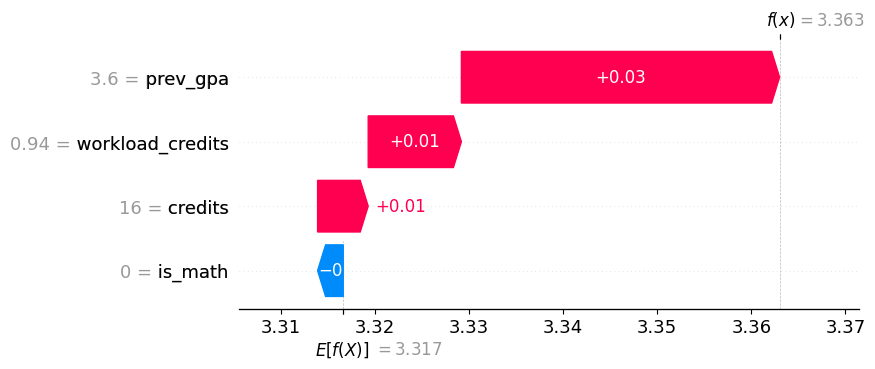

In [14]:
import shap
import matplotlib.pyplot as plt
explainer=shap.TreeExplainer(rf)
next_semester = np.array([[3.6, 16, 0, 0.94]])
shap_values=explainer.shap_values(next_semester)
shap.waterfall_plot(shap.Explanation(values=shap_values[0], base_values=float(explainer.expected_value[0]), data=next_semester[0], feature_names=features))